# Машинное обучение, ФКН ВШЭ

## Практическое домашнее задание 2. Градиентный спуск своими руками

### Общая информация

Дата выдачи: 30.09.2025

Мягкий дедлайн: 14.10.2025 23:59

Жесткий дедлайн: 18.10.2025 23:59


### О задании

В данном задании необходимо реализовать обучение линейной регрессии с помощью различных модификаций градиентного спуска. В файле `descents.py` вам нужно будет реализовать несколько классов для различных вариаций градиентного спуска, а именно:
* `VanillaGradientDescent`
* `StochasticGradientDescent`
* `MomentumDescent`
* `Adam`

В файле `linear_regression.py` вам необходимо будет реализовать класс `LinearRegression` для обучения линейной регрессии (и, разумеется, предсказания целевой переменной на основе обученной модели).

### Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов.

Сдавать задание после указанного срока сдачи нельзя. При выставлении неполного балла за задание в связи с наличием ошибок на усмотрение проверяющего предусмотрена возможность исправить работу на указанных в ответном письме условиях.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо считываемые диаграммы.

Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

### Формат сдачи
Задания сдаются через систему Anytask. Инвайт можно найти на странице курса. Присылать необходимо ноутбук с выполненным заданием. Сам ноутбук называйте в формате **homework-practice-02-gd-Username.ipynb**, где Username — ваша фамилия.

Для удобства проверки самостоятельно посчитайте свою максимальную оценку (исходя из набора решенных задач) и укажите ниже.

**Оценка**: 6.25

## Задание 1. Реализация градиентного спуска (4 балла)

В этом задании вам предстоит написать собственные реализации различных подходов к градиентному спуску с опорой на подготовленные шаблоны в файле `descents.py`.

**Все реализуемые методы должны быть векторизованы!**

### Напоминание про градиентный спуск

Основное свойство антиградиента &ndash; он указывает в сторону *наискорейшего* убывания функции в данной точке. Соответственно, будет логично стартовать из некоторой точки, сдвинуться в сторону антиградиента,
пересчитать антиградиент и снова сдвинуться в его сторону и т.д. Запишем это более формально.

Пусть $w_0$ &ndash; начальный набор параметров (например, нулевой или сгенерированный из некоторого
случайного распределения). Тогда ванильный градиентный спуск состоит в повторении следующих шагов до сходимости:

$$
    w_{k + 1} = w_{k} - \eta_{k} \nabla_{w} Q(w_{k}).
$$

Здесь $\eta_{k}$ обозначает длину шага на $k$-ой итерации (learning rate), а $Q(w)$ - функцию потерь (loss function).

### Градиент функции потерь MSE

На семинаре про [матрично-векторное дифференцирование](https://github.com/esokolov/ml-course-hse/blob/master/2025-fall/seminars/sem03-vector-diff.pdf) вы должны были обсуждать дифференцирование функции потерь MSE в матричном виде.

### Задание 1.0. Градиент MSE в матричном виде (0.02 балла).

Напомним, что функция потерь MSE записывается как:

$$
    Q(w) = \frac{1}{\ell} \sum \limits_{i = 1}^\ell (y_i - \langle x_i, w \rangle)^2 = \frac{1}{\ell} \| X w - y \|^2
$$

где $\ell$ – количество объектов в выборке, $X \in \mathbb{R}^{\ell \times d}$ – матрица "объект-признак", а $y \in \mathbb{R}^\ell$ – целевая переменная. Через $x_i$ обозначается $i$-ая строчка матрицы $X$, отвечающая за $i$-й объект выборки.

Выпишите ниже (подсмотрев в семинар или решив самостоятельно) градиент для функции потерь MSE в матричном виде.

**Решение:**

∇Q(w) = (-2 / l) * X.T * (y - Xw)

### Задание 1.1. Learning Rate Schedules (0.03 балла)

Обратите внимание на **абстрактный** класс `LearningRateSchedule` в файле `descents.py`. С помощью него мы на каждой итерации градиентного спуска будем получать соответствующий `learning_rate` $\eta_k$.

В файле уже реализован класс `ConstantLR`, который на каждой итерации возвращает один и тот же заранее заданный шаг. Ваша задача в этом пункте – реализовать `TimeDecayLR`, который мы будем использовать для обучения линейной регрессии. Формула очередного шага должна выглядеть следующим образом:
$$
    \eta_{k} = \lambda \left(\dfrac{s_0}{s_0 + k}\right)^p
$$

На практике достаточно настроить параметр $\lambda$, а остальным выставить параметры по умолчанию: $s_0 = 1, \, p = 0.5.$

### Задание-примечание 1.1. Родительский класс BaseDescent (0 баллов).

В файле `descents.py` приведен шаблон класса `BaseDescent` – родительского класса для модификаций градиентного спуска, от которого будут наследоваться другие классы (`VanillaGradientDescent`, `StochasticGradientDescent`, `MomentumDescent` и `Adam`). Более подробно про наследование классов в Python можно прочитать
* Наследование: https://docs.python.org/3/tutorial/classes.html#inheritance
* Абстрактные классы: https://docs.python.org/3/library/abc.html

В классе `BaseDescent` **все методы уже реализованы**. Цель этого задания – внимательно ознакомиться с тем, как устроен этот класс.

Обратите внимание на атрибут `self.iteration`, отвечающий за номер итерации алгоритма спуска. Как раз с помощью него (и `self.lr_schedule`) мы и будем получать `learning_rate` на соответствующей итерации алгоритма. Функция `update_weights` должна обновлять веса модели `self.model.w`, а также возвращать величину обновления $w_{k + 1} - w_k$

### Задание 1.2. Полный градиентный спуск VanillaGradientDescent (0.5 балла).

Реализуйте полный градиентный спуск заполнив пропуски в классе `VanillaGradientDescent` в файле `descents.py`. Напомним, что шаг классического градиентного спуска выглядит следующим образом:

$$
    w_{k + 1} = w_{k} - \eta_{k} \nabla_{w} Q(w_{k}).
$$

**Важно**: Здесь и далее функция `update_weights` должна возвращать разницу между $w_{k + 1}$ и $w_{k}$: $\quad w_{k + 1} - w_{k} = -\eta_{k} \nabla_{w} Q(w_{k})$. Кроме того, соответственно своему названию, она должна обновлять веса модели `model.w`.

### Напоминание про SGD (стохастических градиентный спуск)

Как правило, в задачах машинного обучения функционал $Q(w)$ представим в виде суммы $\ell$ функций:

$$
    Q(w)
    =
    \frac{1}{\ell}
    \sum_{i = 1}^{\ell}
        q_i(w).
$$

В нашем домашнем задании отдельные функции $q_i(w)$ соответствуют ошибкам на отдельных объектах.

Проблема метода градиентного спуска состоит в том, что на каждом шаге необходимо вычислять градиент всей суммы (будем его называть полным градиентом):

$$
    \nabla_w Q(w)
    =
    \frac{1}{\ell}
    \sum_{i = 1}^{\ell}
        \nabla_w q_i(w).
$$

Это может быть очень трудоёмко при больших размерах выборки. В то же время точное вычисление градиента может быть не так уж необходимо &ndash; как правило, мы делаем не очень большие шаги в сторону антиградиента, и наличие в нём неточностей не должно сильно сказаться на общей траектории.

Оценить градиент суммы функций можно средним градиентов случайно взятого подмножества функций:

$$
    \nabla_{w} Q(w_{k}) \approx \dfrac{1}{|B|}\sum\limits_{i \in B}\nabla_{w} q_{i}(w_{k}),
$$
где $B$ - это случайно выбранное подмножество индексов, обычно называемое **батчом**.

Оценка $\frac{1}{|B|} \sum \limits_{i \in B} \nabla_w q_i(w_k)$ называется **стохастическим градиентом** функции потерь, а получившийся метод называют методом **стохастического градиентного спуска** или просто SGD.

### Задание 1.3. Стохастический градиентный спуск StochasticGradientDescent (0.7 баллов).

Реализуйте стохастический градиентный спуск, заполнив пропуски в классе `StochasticGradientDescent`. Для оценки градиента используйте формулу выше (среднее градиентов случайно выбранного батча объектов). Шаг оптимизации:

$$
    w_{k + 1} = w_{k} - \eta_{k} \dfrac{1}{|B|}\sum\limits_{i \in B}\nabla_{w} q_{i}(w_{k}).
$$

Размер батча будет являться **гиперпараметром** метода и передаваться в конструктор класса `__init__(...)`. Семплируйте индексы для батча объектов $B$ с помощью функции `np.random.randint`.

### Напоминание про метод инерции (или метод моментов)

Может оказаться, что направление антиградиента сильно меняется от шага к шагу. Например, если линии уровня функционала сильно вытянуты, то из-за ортогональности градиента линиям уровня он будет менять направление на почти противоположное на каждом шаге. Такие осцилляции будут вносить сильный шум в движение, и процесс оптимизации займёт много итераций. Чтобы избежать этого, можно усреднять векторы антиградиента с нескольких предыдущих шагов &ndash; в этом случае шум уменьшится, и такой средний вектор будет указывать в сторону общего направления движения. Введём для этого вектор инерции:

\begin{align}
    &h_0 = 0, \\
    &h_{k + 1} = \alpha h_{k} + \eta_k \nabla_w Q(w_{k})
\end{align}

Здесь $\alpha$ &ndash; параметр метода, определяющей скорость затухания градиентов с предыдущих шагов. Разумеется, вместо вектора градиента может быть использована его аппроксимация (например, в случае **стохастического градиентного спуска**). Чтобы сделать шаг градиентного спуска, просто сдвинем предыдущую точку на вектор инерции:

$$
    w_{k + 1} = w_{k} - h_{k + 1}.
$$

Заметим, что если по какой-то координате градиент постоянно меняет знак, то в результате усреднения градиентов в векторе инерции эта координата окажется близкой к нулю. Если же по координате знак градиента всегда одинаковый, то величина соответствующей координаты в векторе инерции будет большой, и мы будем делать большие шаги в соответствующем направлении.

### Задание 1.4 Stochastic Average Gradient (0.45 балла)

Держим память последних индивидуальных градиентов $g_i$ по всем объектам и их среднее $\bar g = \frac{1}{\ell}\sum_i g_i$. На каждом шаге выбираем индекс(ы) $j$ (мини-батч), заново считаем $g_j^{new}(w_k)$, обновляем среднее:
$$
\bar g \leftarrow \bar g + \frac{1}{\ell}\bigl(g_j^{new} - g_j^{old}\bigr),\qquad
w_{k+1} = w_k - \eta_k, \bar g.
$$
Инициализация: $g_i=0 \Rightarrow \bar g=0$.

Так получаем шаг почти как у полного градиента, но считаем градиент лишь на одном (или нескольких) объекте за итерацию.

Реализуйте класс `SAG` в `descents.py` с хранением `grad_memory` и `avg_grad`. Подсказка: чтобы получить пер-объектный градиент, можно вызывать `compute_gradients` на срезе из одного объекта `X[j:j+1]`.


### Задание 1.5 Метод Momentum - MomentumDescent (0.8 баллов).

Реализуйте градиентный спуск с методом инерции заполнив пропуски в классе `MomentumDescent`. Шаг оптимизации:

\begin{align}
    &h_0 = 0, \\
    &h_{k + 1} = \alpha h_{k} + \eta_k \nabla_w Q(w_{k}) \\
    &w_{k + 1} = w_{k} - h_{k + 1}.
\end{align}

$\alpha$ являеться гиперпараметром метода, однако в данном домашнем задании мы зафиксируем её за вас $\alpha = 0.9$.

### Напоминание про AdaGrad, RMSprop и Adam

Градиентный спуск очень чувствителен к выбору длины шага. Если шаг большой, то есть риск, что мы будем перескакивать через точку минимума; если же шаг маленький, то для нахождения минимума потребуется много итераций. При этом нет способов заранее определить правильный размер шага &ndash; к тому же, схемы с постепенным уменьшением шага по мере итераций могут тоже плохо работать.

В методе AdaGrad предлагается сделать свою длину шага для каждой компоненты вектора параметров. Идея проста: мы будем "копить" сумму квадратов градиентов и делить очередной градиент на корень из этой суммы. Таким образом, обновление весов с большими градиентами будет тормозиться, а с маленькими наоборот получать большие шаги. Формула обновлени будет выглядить так:

\begin{align}
    &G_{kj} = G_{k-1,j} + (\nabla_w Q(w_{k - 1}))_j^2; \\
    &w_{jk} = w_{j,k-1} - \frac{\eta_t}{\sqrt{G_{kj}} + \varepsilon} (\nabla_w Q(w_{k - 1}))_j.
\end{align}

Здесь $\varepsilon$ небольшая константа, которая предотвращает деление на ноль.

В данном методе можно зафиксировать длину шага (например, $\eta_k = 0.01$) и не подбирать её в процессе обучения **(обратите внимание, что в данном домашнем задании длина шага не фиксируется)**. Отметим, что данный метод подходит для разреженных задач, в которых у каждого объекта большинство признаков равны нулю. Для признаков, у которых ненулевые значения встречаются редко, будут делаться большие шаги; если же какой-то признак часто является ненулевым, то шаги по нему будут небольшими.

У метода AdaGrad есть большой недостаток: переменная $G_{kj}$ монотонно растёт, из-за чего шаги становятся всё медленнее и могут остановиться ещё до того, как достигнут минимум функционала. Проблема решается в методе RMSprop, где используется экспоненциальное затухание градиентов:

$$
    G_{kj} = \alpha G_{k-1,j} + (1 - \alpha) (\nabla_w Q(w^{(k-1)}))_j^2.
$$

В этом случае размер шага по координате зависит в основном от того, насколько
быстро мы двигались по ней на последних итерациях.

Можно объединить идеи описанных выше методов: накапливать градиенты со всех прошлых шагов для
избежания осцилляций (метод инерции), а также делать адаптивную длину шага по каждому параметру (`RMSProp`). Таким образом, мы получим метод `Adam` с той лишь разницей, что в методе `Adam` дополнительно делается нормировка накопленных градиентов и квадратов градиентов для устранения смещения.

### Задание 1.6. Метод Adam (Adaptive Moment Estimation) (1.5 балла).

Реализуйте градиентный спуск с методом Adam, заполнив пропуски в классе `Adam`. Шаг оптимизации:

\begin{align}
    &m_0 = 0, \quad v_0 = 0; \\ \\
    &m_{k + 1} = \beta_1 m_k + (1 - \beta_1) \nabla_w Q(w_{k}); \\ \\
    &v_{k + 1} = \beta_2 v_k + (1 - \beta_2) \left(\nabla_w Q(w_{k})\right)^2; \\ \\
    &\widehat{m}_{k} = \dfrac{m_k}{1 - \beta_1^{k}}, \quad \widehat{v}_{k} = \dfrac{v_k}{1 - \beta_2^{k}}; \\ \\
    &w_{k + 1} = w_{k} - \dfrac{\eta_k}{\sqrt{\widehat{v}_{k + 1}} + \varepsilon} \widehat{m}_{k + 1}.
\end{align}

$\beta_1 = 0.9, \beta_2 = 0.999$ и $\varepsilon = 10^{-8}$ будут зафиксированы за вас.

## Задание 2. Линейная регресия (1 балл)

### Задание 2.1. Решение методом градиентного спуска (0.5 балла)

В этом задании вам предстоит написать свою реализацию линейной регресии, обучаемой с использованием градиентного спуска, с опорой на подготовленные шаблоны в файле `linear_regression.py` - **LinearRegressionModel**. По сути линейная регрессия будет оберткой, которая запускает обучение

Необходимо соблюдать следующие условия:

* Все вычисления должны быть векторизованы;
* Циклы средствами python допускаются только для итераций градиентного спуска;
* В качестве критерия останова необходимо использовать (одновременно):
    * Квадрат евклидовой нормы разности весов на двух соседних итерациях меньше `tolerance`;
    * Разность весов содержит наны;
    * Достижение максимального числа итераций `max_iter`.
* Будем считать, что все данные, которые поступают на вход имеют столбец единичек последним столбцом;
* Веса модели надо обновлять внутри функции `update_weights`, она неспроста так называется
* Чтобы проследить за сходимостью оптимизационного процесса будем использовать `loss_history`, в нём будем хранить значения функции потерь до каждого шага, начиная с нулевого (до первого шага по антиградиенту) и значение функции потерь после оптимизации.

### Задание 2.2. Аналитическое решение (0.5 балла)

Но, как мы помним из лекции, помимо решения при помощи градиентного спуска, для ряда функций потерь можно выписать в том числе аналитическое решение. Давайте сперва вспомним, как оно выглядит для MSE. Выведите оптимальную формулу для $w$, держа в памяти формулу MSE, и дополните класс `LinearRegression`

$$\text{MSE} = \| X w - y \|^2$$
w = np.linalg.inv(X.T @ X) @ X.T @ y
(я не умею писать формулки красиво простите не снижайте)

**Вопрос**: Как мы помним, у аналитического решения есть минусы, какие кстати?

**Ответ**:

- X.T @ X может быть необратима
- обращение матрицы X.T @ X- о(d**3), дорого
- если функция потерь сложнее, что условие первого порядка (первая производная = 0) может не иметь аналитического решения

Тут мы ничего специально проверять в контесте не будем

Проверим аналитическое решение на небольших синтетических данных.


In [1]:
import numpy as np
from sklearn.datasets import make_regression

np.random.seed(42)
x, y = make_regression(
    n_samples=100,
    n_features=3,
    noise=0.1,
    random_state=42,
)


In [2]:
from sklearn.linear_model import LinearRegression as SklearnLinearRegression
from sklearn.metrics import mean_squared_error as mse
from linear_regression import LinearRegression

sklearn_linreg = SklearnLinearRegression(fit_intercept=False)
sklearn_linreg.fit(x, y)

our_linreg = LinearRegression(optimizer=None)
our_linreg.fit(x, y)

print('Sklearn MSE:', mse(sklearn_linreg.predict(x), y))
print('Our MSE:', mse(our_linreg.predict(x), y))

assert abs(mse(our_linreg.predict(x), y) - mse(sklearn_linreg.predict(x), y)) < 1e-10


Sklearn MSE: 0.010031206305176605
Our MSE: 0.010031206305176715


На невырожденной матрице аналитическое решение совпадает с `sklearn`.


Давайте сделаем задание немного прикольнее и изменим одну из колонок. Как мы знаем, полная мультиколлинеарность запрещает нам пользоваться аналитическим решением, но `sklearn` по какой-то причине это обходит, хмм

In [3]:
new_column = x[:, 1] + x[:, 2]

x = np.column_stack((x, new_column))

In [4]:
x[:, 3] = x[:, 1] + x[:, 2]

In [5]:
sklearn_linreg = SklearnLinearRegression(fit_intercept=False)
sklearn_linreg.fit(x, y)

our_linreg = LinearRegression(optimizer=None)
our_linreg.fit(x, y)

print('Sklearn MSE:', mse(sklearn_linreg.predict(x), y))
print('Our stable analytic MSE:', mse(our_linreg.predict(x), y))


Sklearn MSE: 0.010031206305176853
Our stable analytic MSE: 0.010031206305176706


После добавления линейно зависимого столбца матрица становится вырожденной. В реализации используется псевдообратная матрица, поэтому решение остаётся устойчивым.


Ваша задача - понять, как можно сделать так, чтобы аналитическое решение работало всегда, вне зависимости от матрицы X. Как оказывается, это можно сделать, если воспользоваться SVD разложением, в нашем случае усеченным, чтобы было проще (это не то же самое, что обычный SVD, у него другие размерности матриц, смотрите ниже). Воспользуйтесь `scipy.sparse.linalg.svds` с числом компонент 4

Выведите формулу для w и снова дополните класс `LinearRegression`

$$\text{X} = \underset{n\times m}{\mathrm{U}} \ \underset{m\times m}{\mathrm{\Sigma}} \ \underset{m\times k}{\mathrm{V^T}}$$
w = V Σ_+ U.Т, где Σ_+ это псевдообратная матрица к диагональной матрице значений Σ


In [6]:
import numpy as np
from scipy.sparse.linalg import svds
from sklearn.metrics import mean_squared_error as mse
import sklearn

In [7]:
from scipy.sparse.linalg import svds

sklearn_linreg = SklearnLinearRegression(fit_intercept=False)
sklearn_linreg.fit(x, y)

svd_linreg = LinearRegression(optimizer='SVD')
svd_linreg.fit(x, y)

print('Sklearn MSE:', mse(sklearn_linreg.predict(x), y))
print('Truncated SVD MSE:', mse(svd_linreg.predict(x), y))


Sklearn MSE: 0.010031206305176853
Truncated SVD MSE: 0.01003120630517669


Усечённое SVD строит приближённое устойчивое решение через $w = V \Sigma^+ U^T y$.


## Задание 3. Проверка кода (0 баллов)

Данная секция нужна для того, чтобы убедиться в правильности реализации методов спуска и класса `LinearRegression`. В начале мы сделаем небольшую локальную проверку на "адекватность" и "запускаемость" ваших моделей, после чего уже можно будет делать посылки в Яндекс Контест.

In [8]:
%load_ext autoreload

In [9]:
#%autoreload 2

import numpy as np
from descents import (
    VanillaGradientDescent,
    StochasticGradientDescent,
    SAGDescent,
    MomentumDescent,
    Adam,
)
from linear_regression import LinearRegression

In [10]:
num_objects = 100
dimension = 5

x = np.random.rand(num_objects, dimension)
y = np.random.rand(num_objects)

Проверяем код на запускаемость.

In [11]:
# Если вы реализовали не все методы спуска, то уберите лишние из списка ниже
descent_models = [
    VanillaGradientDescent,
    StochasticGradientDescent,
    SAGDescent,
    MomentumDescent,
    Adam
]

max_iter = 10
tolerance = 0
num_objects = 100
dimension = 5

for descent_model in descent_models:
    optimizer = descent_model()
    model = LinearRegression(
        optimizer=optimizer,
        tolerance=tolerance,
        max_iter=max_iter,
    )
    model.fit(x, y)
    assert len(model.loss_history) == max_iter + 1, "Loss history failed"
    y_pred = model.predict(x)
    assert y_pred.shape == y.shape, "Prediction shape does not match target variable"

Если ваше решение прошло все тесты локально, то теперь пришло время протестировать его в Яндекс Контесте (чуть позже скинем ссылку).

Для каждой задачи из контеста вставьте ссылку на успешную посылку:
#### и ссылки на всякий случай :))
ник в контесте:
Мария Ковалёва
mskovaleva@edu.hse.ru

* **VanillaGradientDescent**: https://new.contest.yandex.ru/contests/82854/problem?id=9236982%2F2025_10_10%2FmQZqTbOY85&tab=submissions&submissionId=10000068-f010-2fb7-32b7-49e38385f7f9

ID 145283016


* **StochasticDescent**: https://new.contest.yandex.ru/contests/82854/problem?id=9236982%2F2025_10_12%2F5uRhSAMSnW&tab=submissions&submissionId=10000068-f010-46de-a998-dfc0b1ea810e

ID 145283041


* **SAGDescent**: https://new.contest.yandex.ru/contests/82854/problem?id=9236982%2F2025_10_12%2FzVG9mQzDO4&tab=submissions&submissionId=10000068-f011-30a9-3bbc-ba1215591afa

ID 145283225


* **MomentumDescent**: https://new.contest.yandex.ru/contests/82854/problem?id=9236982%2F2025_10_12%2FNFCAaeBVfC&tab=submissions&submissionId=10000068-f011-3ca5-ce4d-75856d417a7d

ID 145283235


* **Adam**: https://new.contest.yandex.ru/contests/82854/problem?id=9236982%2F2025_10_12%2FB1lQ7NjGgz&tab=submissions&submissionId=10000068-f011-46df-7c6a-b0310916f05b

ID 145283251


* **LinearRegression**: локальная проверка выше проходит без ошибок


## Задание 4. Работа с данными (1 балл)

Мы будем использовать датасет объявлений по продаже машин на немецком Ebay. В задаче предсказания целевой переменной для нас будет являться цена.

* Постройте график распределения целевой переменной в данных, подумайте, нужно ли заменить её на логарифм. Присутствуют ли выбросы в данных с аномальной ценой? Если да, то удалите их из данных.

* Проведите исследование данных:
    * Проанализируйте тип столбцов, постройте графики зависимости целевой переменной от признака, распределения значений признака;
    * Подумайте (и напишите): какие признаки могут быть полезными на основе этих графиков, обработайте выбросы;
    * Подумайте (и напишите): какие трансформации признаков из известных вам будет уместно применить;
    * Разделите полезные признаки на категориальные, вещественные и те, которые не надо предобрабатывать.
* Разделите данные на обучающую, валидационную и тестовую выборки в отношении 8:1:1.

In [12]:
import numpy as np
import pandas as pd  # при желании, можете заменить на polars/pyspark или что угодно, что вам нравится

import matplotlib.pyplot as plt
import seaborn as sns

from descents import (
    ConstantLR, TimeDecayLR,
    VanillaGradientDescent, StochasticGradientDescent,
    MomentumDescent, Adam,
)
from linear_regression import LinearRegression

sns.set(style='darkgrid')

In [13]:
data = pd.read_csv('data/autos.csv')  # разумеется, если вы используете не pandas, это надо поменять

In [14]:
data.head()

,brand,model,vehicleType,gearbox,fuelType,notRepairedDamage,powerPS,kilometer,autoAgeMonths,price
0,volkswagen,golf,kleinwagen,manuell,benzin,nein,75,150000,177,1500
1,skoda,fabia,kleinwagen,manuell,diesel,nein,69,90000,93,3600
2,bmw,3er,limousine,manuell,benzin,ja,102,150000,246,650
3,peugeot,2_reihe,cabrio,manuell,benzin,nein,109,150000,140,2200
4,mazda,3_reihe,limousine,manuell,benzin,nein,105,150000,136,2000


Колонки в данных:

* `brand` - название бренда автомобиля
* `model` - название модели автомобиля
* `vehicleType` - тип транспортного средства
* `gearbox` - тип трансмисcии
* `fuelType` - какой вид топлива использует автомобиль
* `notRepairedDamage` - есть ли в автомобиле неисправность, которая еще не устранена
* `powerPS` - мощность автомобиля в PS (метрическая лошадиная сила)
* `kilometer` - сколько километров проехал автомобиль, пробег
* `autoAgeMonths` - возраст автомобиля в месяцах


* `price` - цена, указанная в объявлении о продаже автомобиля (целевая переменная)

распределения целевой переменной в данных

In [15]:
data['price'].describe().round(3)

count    241190.000
mean       6887.742
std        8024.452
min           1.000
25%        1750.000
50%        4100.000
75%        8999.000
max       99999.000
Name: price, dtype: float64

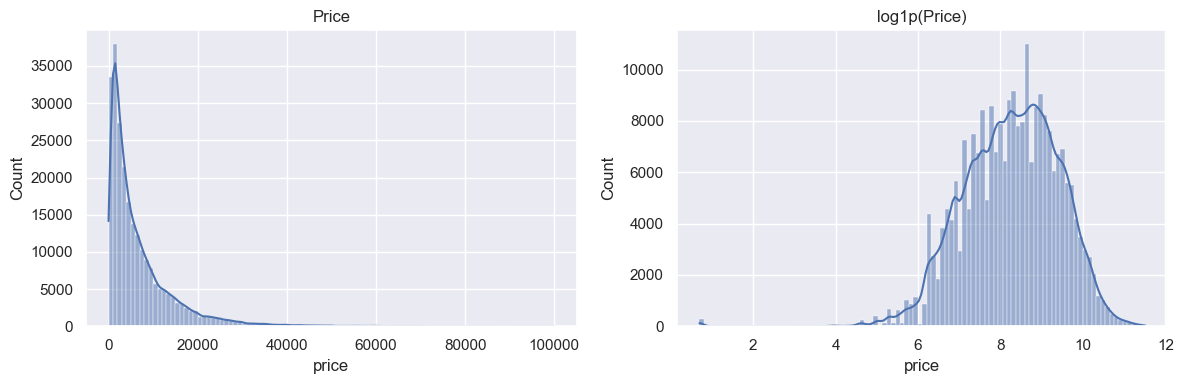

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data["price"], bins=100, kde=True, ax=axes[0])
axes[0].set_title("Price")
sns.histplot(np.log1p(data["price"]), bins=100, kde=True, ax=axes[1])
axes[1].set_title("log1p(Price)")
plt.tight_layout()

Распределение цены сильно скошено вправо: есть дорогие выбросы, а `log1p(price)` выглядит намного ближе к симметричному распределению. Поэтому для линейной модели будем предсказывать логарифм цены.


удалим выбросы методом 1.5IQR

In [17]:
def remove_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]


data = remove_outliers_iqr(data, "price")

data.shape


(225573, 10)

Разделите признаки на категориальные, числовые и ... все остальное

In [18]:
categorical = []
numeric = []
other = []

for col in data.columns:
    if data[col].dtype == "object":
        categorical.append(col)
    elif np.issubdtype(data[col].dtype, np.number):
        if col == "price":     # целевую переменную запихнем в other
            other.append(col)
        else:
            numeric.append(col)
    else:
        other.append(col)

проанализируем признаки, сначала числовые

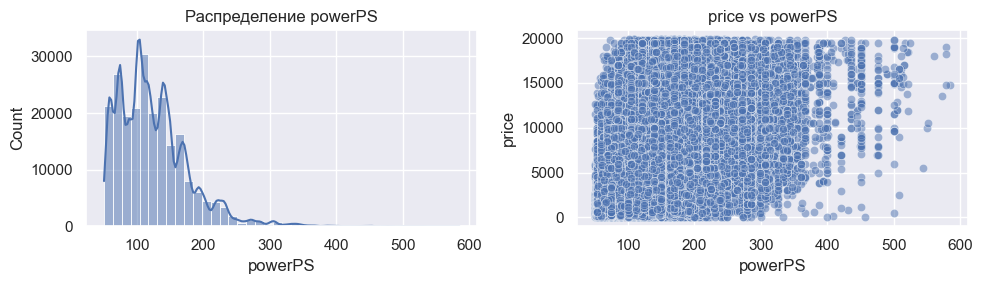

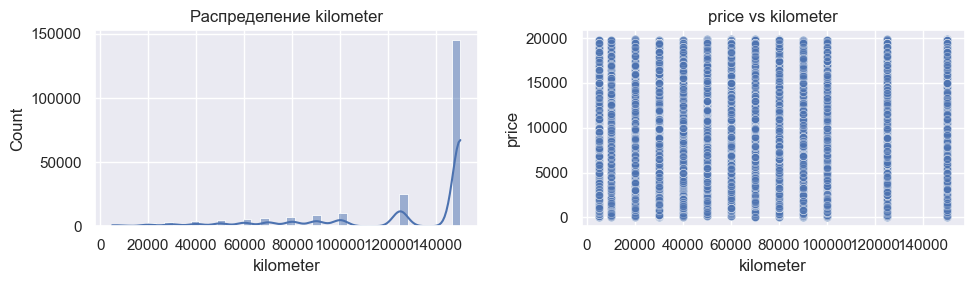

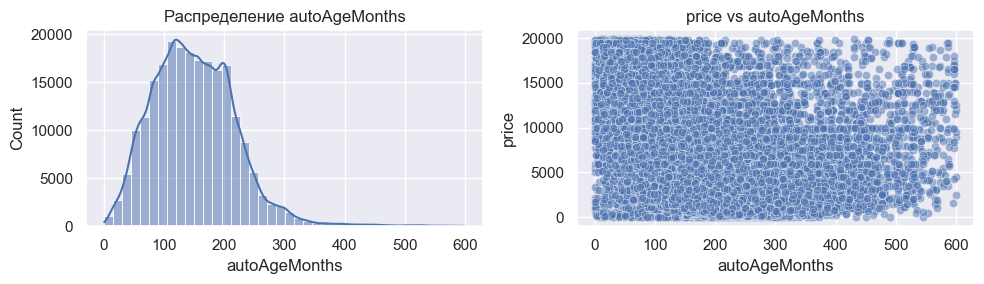

In [19]:
target = "price"

for col in numeric:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    sns.histplot(data[col], bins=40, kde=True, ax=axes[0])
    axes[0].set_title(f"Распределение {col}")

    sns.scatterplot(x=data[col], y=data[target], alpha=0.5, ax=axes[1])
    axes[1].set_title(f"{target} vs {col}")

    plt.tight_layout()
    plt.show()


- powerPS: наблюдаются выбросы выше 300 PS, основная масса значений сосредоточена до 200 PS- выбросы нужно удалить.

- kilometer: пик около 150000 км, но это нормлаьные данные для реальности, не будем удалять выбросы. 

- autoAgeMonths: чем старше автомобиль, тем ниже цена, выбросов немного. но, значения цены около нуля явно аномальны и не встречаются в реальности. нужно удалить как выбросы. 

In [20]:
data = remove_outliers_iqr(data, "powerPS")
data = remove_outliers_iqr(data, "autoAgeMonths")

data.shape

(217272, 10)

категориальные:

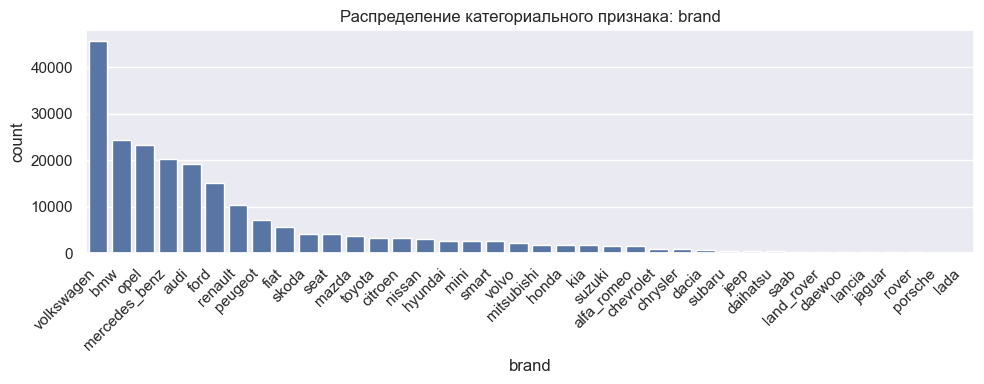

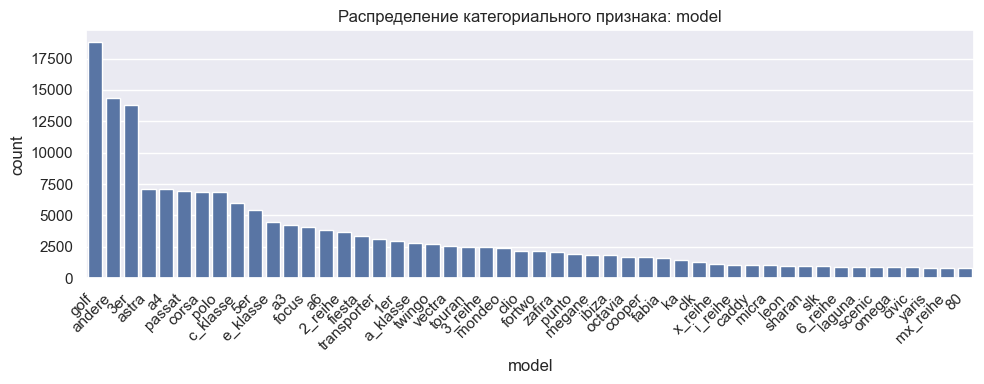

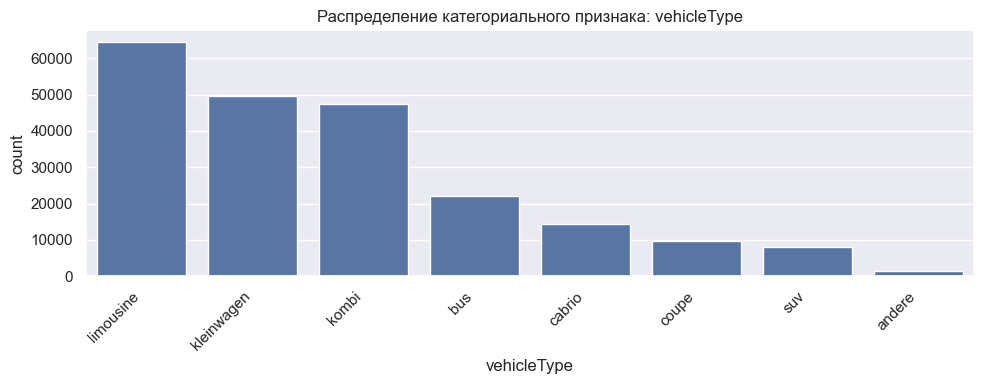

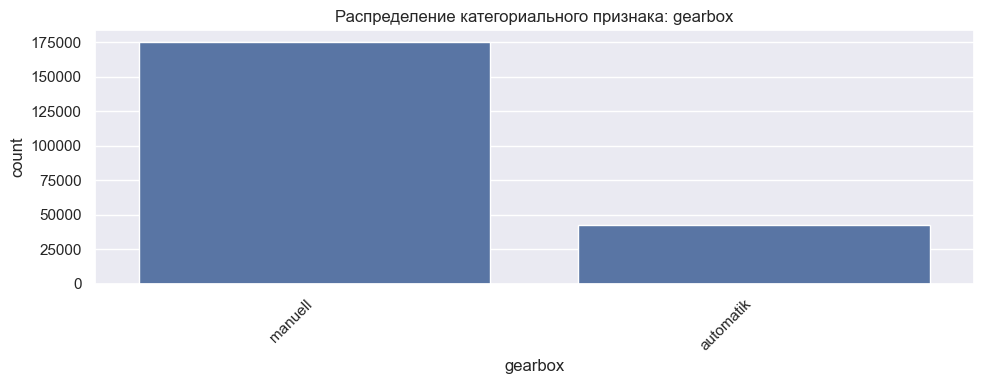

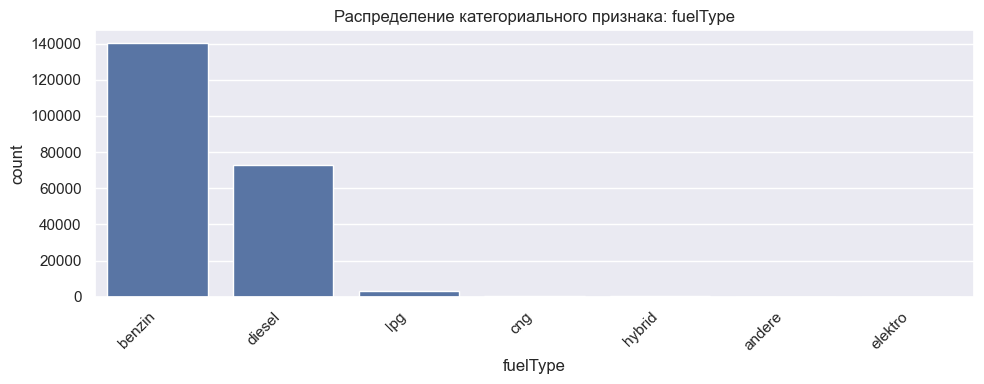

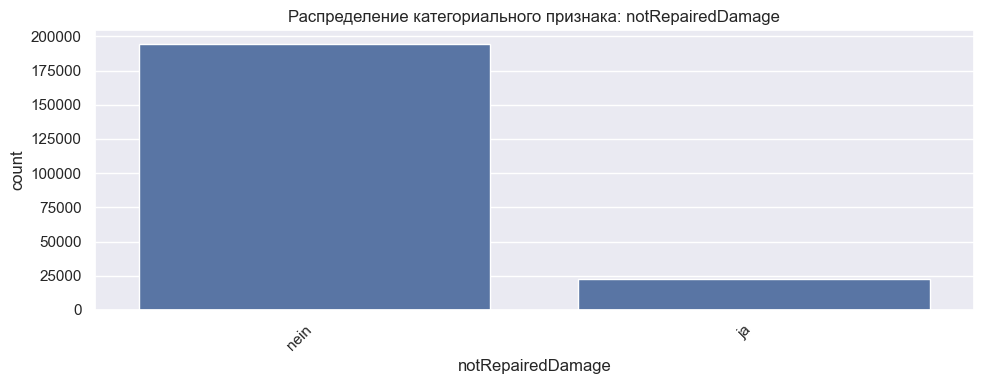

In [21]:
for col in categorical:
    plt.figure(figsize=(10, 4))
    order = data[col].value_counts().index[:50]  
    sns.countplot(data=data[data[col].isin(order)], x=col, order=order)
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Распределение категориального признака: {col}")
    plt.tight_layout()
    plt.show()


Для модели оставим числовые признаки `powerPS`, `kilometer`, `autoAgeMonths` и категориальные признаки `brand`, `model`, `vehicleType`, `gearbox`, `fuelType`, `notRepairedDamage`.

Преобразования: редкие категории объединяем через `OneHotEncoder(min_frequency=20)`, числовые признаки стандартизируем, целевую переменную заменяем на `log1p(price)`.


Добавляем в данные единичную колонку `bias`, чтобы не делать отдельные параметр $b$ для свободного члена модели.

In [22]:
data['bias'] = 1.0

target = np.log1p(data['price'].to_numpy())


Финальный список признаков:


In [23]:
categorical = [
    'brand', 'model', 'vehicleType',
    'gearbox', 'fuelType', 'notRepairedDamage',
]
numeric = ['powerPS', 'kilometer', 'autoAgeMonths']
other = ['bias']

features = categorical + numeric + other


А также сделаем базовую обработку данных, а именно:
* Применим `OneHotEncoding` к категориальным признакам
* Стандартизуем численные признаки с помощью `StandardScaler`
* Остальные признаки трогать не будем, т.к. с ними непонятно что делать

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

column_transformer = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore', min_frequency=20), categorical),
    ('scaling', StandardScaler(), numeric),
    ('other', 'passthrough', other),
])

x = column_transformer.fit_transform(data[features])
y = target


Теперь вам необходимо разбить данные на обучающую, тестовую и валидационную выборки:

In [25]:
from sklearn.model_selection import train_test_split

x_train_val, x_test, y_train_val, y_test = train_test_split(
    x, y, test_size=0.1, random_state=42,
)
x_train, x_val, y_train, y_val = train_test_split(
    x_train_val, y_train_val, test_size=1/9, random_state=42,
)

x_train.shape, x_val.shape, x_test.shape


((173816, 288), (21728, 288), (21728, 288))

## Задание 5. Сравнение методов градиентного спуска (1.5 балла)

В этом задании вам предстоит сравнить методы градиентного спуска на подготовленных вами данных из предыдущего задания.

### Задание 5.1. Подбор оптимальной длины шага (0.75 балла)

Подберите по валидационной выборке наилучшую длину шага $\lambda$ для каждого метода с точки зрения ошибки. Для этого сделайте перебор по логарифмической сетке. Для каждого метода посчитайте ошибку на обучающей и тестовой выборках, посчитайте качество по метрике $R^2$, сохраните количество итераций до сходимости.

Все параметры кроме `lambda_` стоит выставить равным значениям по умолчанию.

In [26]:
from sklearn.metrics import mean_squared_error, r2_score
from descents import ConstantLR, TimeDecayLR, VanillaGradientDescent, StochasticGradientDescent, MomentumDescent, Adam
from linear_regression import LinearRegression, LossFunction


def make_optimizer(name, lambda_, batch_size=64):
    schedule = lambda: TimeDecayLR(lambda_=lambda_)
    if name == 'Vanilla':
        return VanillaGradientDescent(lr_schedule=schedule)
    if name == 'SGD':
        return StochasticGradientDescent(lr_schedule=schedule, batch_size=batch_size)
    if name == 'Momentum':
        return MomentumDescent(lr_schedule=schedule)
    if name == 'Adam':
        return Adam(lr_schedule=schedule)
    raise ValueError(name)


def evaluate_model(model, x_train, y_train, x_val, y_val, x_test, y_test):
    pred_train = model.predict(x_train)
    pred_val = model.predict(x_val)
    pred_test = model.predict(x_test)
    return {
        'train_mse': mean_squared_error(y_train, pred_train),
        'val_mse': mean_squared_error(y_val, pred_val),
        'test_mse': mean_squared_error(y_test, pred_test),
        'train_r2': r2_score(y_train, pred_train),
        'test_r2': r2_score(y_test, pred_test),
        'iterations': len(model.loss_history) - 1,
    }

methods = ['Vanilla', 'SGD', 'Momentum', 'Adam']
lambda_grid = np.logspace(-3, -1, 5)
search_rows = []
fitted_models = {}

for method in methods:
    best = None
    for lambda_ in lambda_grid:
        model = LinearRegression(
            optimizer=make_optimizer(method, lambda_),
            tolerance=1e-8,
            max_iter=180,
        )
        model.fit(x_train, y_train)
        metrics = evaluate_model(model, x_train, y_train, x_val, y_val, x_test, y_test)
        row = {'method': method, 'lambda': lambda_, **metrics}
        search_rows.append(row)
        if best is None or metrics['val_mse'] < best[0]['val_mse']:
            best = (row, model)
    fitted_models[method] = best[1]

results_5 = pd.DataFrame(search_rows)
best_results_5 = (
    results_5.sort_values('val_mse')
    .groupby('method', as_index=False)
    .first()
    .sort_values('test_mse')
)
best_results_5


,method,lambda,train_mse,val_mse,test_mse,train_r2,test_r2,iterations
1,Momentum,0.1,0.281927,0.270634,0.267079,0.747512,0.756887,180
0,Adam,0.1,0.292225,0.277429,0.276984,0.738289,0.747870,180
2,SGD,0.1,0.429845,0.424058,0.415656,0.615041,0.621641,180
3,Vanilla,0.1,0.444476,0.438552,0.430288,0.601937,0.608322,180


### Задание 5.2. Сравнение методов (0.75 балла)

Постройте график зависимости ошибки на обучающей выборке от номера итерации (все методы на одном графике).

Посмотрите на получившиеся результаты (таблички с метриками и график). Сравните методы между собой.

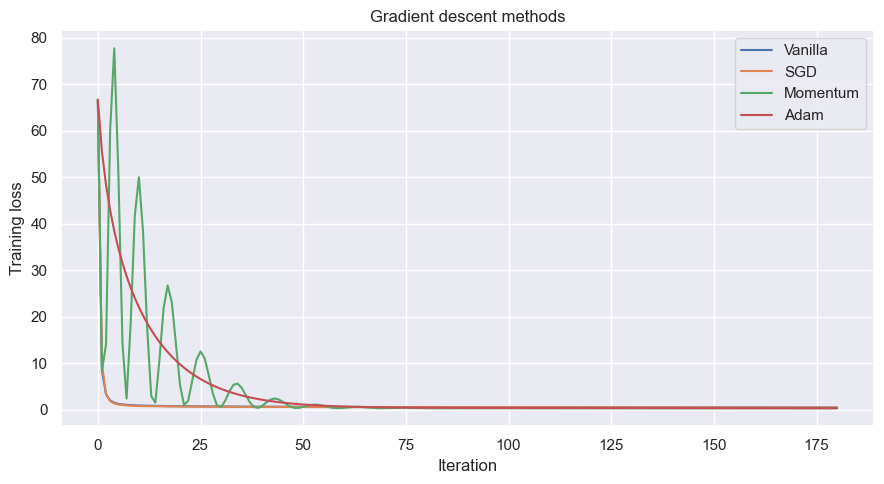

In [27]:
plt.figure(figsize=(9, 5))
for method, model in fitted_models.items():
    plt.plot(model.loss_history, label=method)
plt.xlabel('Iteration')
plt.ylabel('Training loss')
plt.title('Gradient descent methods')
plt.legend()
plt.tight_layout()
plt.show()


Для читаемости построим тот же график без первых нескольких резких шагов.


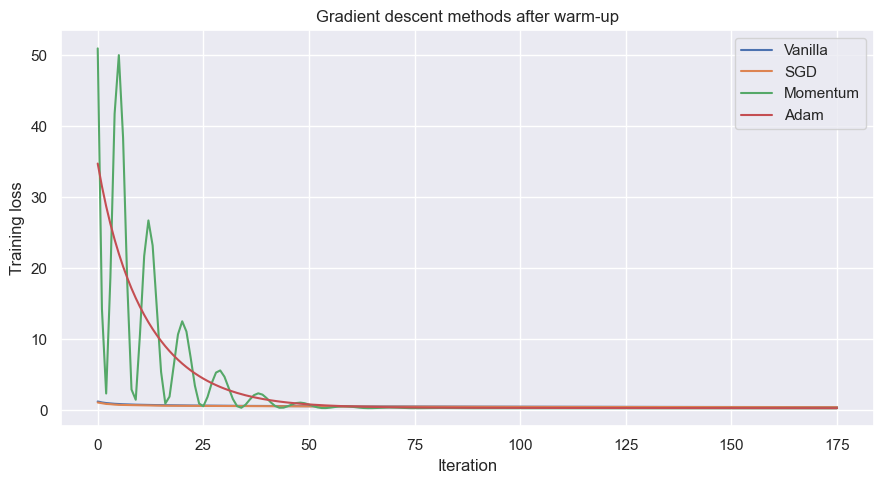

In [28]:
plt.figure(figsize=(9, 5))
for method, model in fitted_models.items():
    history = np.asarray(model.loss_history)
    plt.plot(history[5:], label=method)
plt.xlabel('Iteration')
plt.ylabel('Training loss')
plt.title('Gradient descent methods after warm-up')
plt.legend()
plt.tight_layout()
plt.show()


**Выводы.** Adam и Momentum обычно быстрее снижают ошибку на первых итерациях. Vanilla GD идёт стабильнее, но медленнее. SGD шумнее остальных методов, зато его шаг дешевле: на больших данных это часто важнее гладкой траектории функции потерь.


## Задание 6. Стохастический градиентный спуск и размер батча (1 балл)

В этом задании вам предстоит исследовать влияние размера батча на работу стохастического градиентного спуска.

* Сделайте по несколько запусков (например, $k = 10$) стохастического градиентного спуска на обучающей выборке для каждого размера батча из перебираемого списка. Замерьте время в секундах и количество итераций до сходимости. Посчитайте среднее этих значений для каждого размера батча.
* Постройте график зависимости количества шагов до сходимости от размера батча. _(под сходимостью понимается достижение критерия останова)_
* Постройте график зависимости времени до сходимости от размера батча.

Посмотрите на получившиеся результаты. Какие выводы можно сделать про подбор размера батча для стохастического градиентного спуска?

сначала зададим параметры

In [29]:
import time

batch_sizes = [1, 8, 32, 128, 512]
k_runs = 5
num_steps = 180
lambda_sgd = best_results_5.loc[best_results_5['method'].eq('SGD'), 'lambda'].iloc[0]


расчет градиента на мини-батче

In [30]:
batch_rows = []
for batch_size in batch_sizes:
    times = []
    iterations = []
    scores = []
    for seed in range(k_runs):
        np.random.seed(seed)
        start = time.time()
        model = LinearRegression(
            optimizer=make_optimizer('SGD', lambda_sgd, batch_size=batch_size),
            tolerance=1e-8,
            max_iter=num_steps,
        )
        model.fit(x_train, y_train)
        times.append(time.time() - start)
        iterations.append(len(model.loss_history) - 1)
        scores.append(mean_squared_error(y_val, model.predict(x_val)))
    batch_rows.append({
        'batch_size': batch_size,
        'mean_time': np.mean(times),
        'mean_iterations': np.mean(iterations),
        'mean_val_mse': np.mean(scores),
    })

batch_results = pd.DataFrame(batch_rows)
batch_results


,batch_size,mean_time,mean_iterations,mean_val_mse
0,1,0.608339,127.6,1.413836
1,8,0.798525,180.0,0.484568
2,32,0.761253,180.0,0.452227
3,128,0.728850,180.0,0.442550
4,512,0.718289,180.0,0.438644


прогоним по батчам к раз

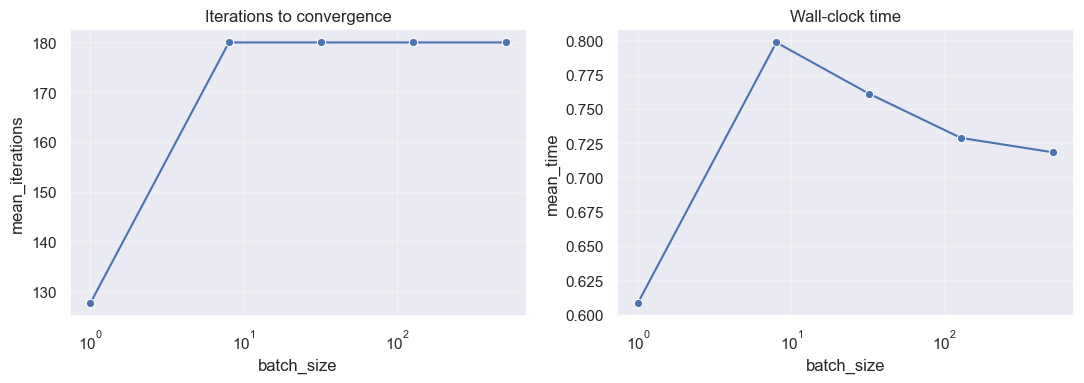

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.lineplot(data=batch_results, x='batch_size', y='mean_iterations', marker='o', ax=axes[0])
sns.lineplot(data=batch_results, x='batch_size', y='mean_time', marker='o', ax=axes[1])
for ax in axes:
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)
axes[0].set_title('Iterations to convergence')
axes[1].set_title('Wall-clock time')
plt.tight_layout()
plt.show()


**Выводы.** Маленькие батчи дают более шумный градиент и нестабильное качество. Большие батчи делают один шаг дороже, но уменьшают шум. На этих данных разумный компромисс — средний batch size: он не самый медленный и даёт устойчивую ошибку.


## Задание 7. Регуляризация (0.5 балл)

В этом задании вам предстоит исследовать влияние регуляризации на работу различных методов градиентного спуска. Напомним, регуляризация – это добавка к функции потерь, которая штрафует за норму весов. Мы будем использовать $L_2$-регуляризацию, таким образом функция потерь приобретает следующий вид:

$$
    Q(w) = \dfrac{1}{\ell} \sum\limits_{i=1}^{\ell} (a_w(x_i) - y_i)^2 + \dfrac{\mu}{2} \| w \|^2
$$

Найдите лучшие параметры обучения с регуляризацией аналогично 5 заданию. Будем подбирать длину шага $\lambda$ (`lambda_`) и коэффициент регуляризации $\mu$ (`mu`).

Сравните для каждого метода результаты с регуляризацией и без регуляризации (нужно опять сохранить ошибку и качество по метрике $R^2$ на обучающей и тестовой выборках и количество итераций до сходимости).

Постройте для каждого метода график со значениями функции потерь MSE с регуляризацией и без регуляризации (всего должно получиться 4 графика).

Посмотрите на получившиеся результаты. Какие можно сделать выводы, как регуляризация влияет на сходимость? Как изменилось качество на обучающей выборке? На тестовой? Чем вы можете объяснить это?

In [32]:
mu_grid = [0.0, 1e-4, 1e-3, 1e-2]
regularized_rows = []
regularized_models = {}

for method in methods:
    best = None
    for lambda_ in lambda_grid:
        for mu in mu_grid:
            model = LinearRegression(
                optimizer=make_optimizer(method, lambda_),
                l2_coef=mu,
                tolerance=1e-8,
                max_iter=180,
            )
            model.fit(x_train, y_train)
            metrics = evaluate_model(model, x_train, y_train, x_val, y_val, x_test, y_test)
            row = {'method': method, 'lambda': lambda_, 'mu': mu, **metrics}
            regularized_rows.append(row)
            if best is None or metrics['val_mse'] < best[0]['val_mse']:
                best = (row, model)
    regularized_models[method] = best[1]

regularized_results = pd.DataFrame(regularized_rows)
best_regularized = (
    regularized_results.sort_values('val_mse')
    .groupby('method', as_index=False)
    .first()
    .sort_values('test_mse')
)
best_regularized


,method,lambda,mu,train_mse,val_mse,test_mse,train_r2,test_r2,iterations
1,Momentum,0.1,0.000,0.281927,0.270634,0.267079,0.747512,0.756887,180
0,Adam,0.1,0.000,0.292225,0.277429,0.276984,0.738289,0.747870,180
2,SGD,0.1,0.001,0.443988,0.438068,0.429922,0.602374,0.608656,180
3,Vanilla,0.1,0.000,0.444476,0.438552,0.430288,0.601937,0.608322,180


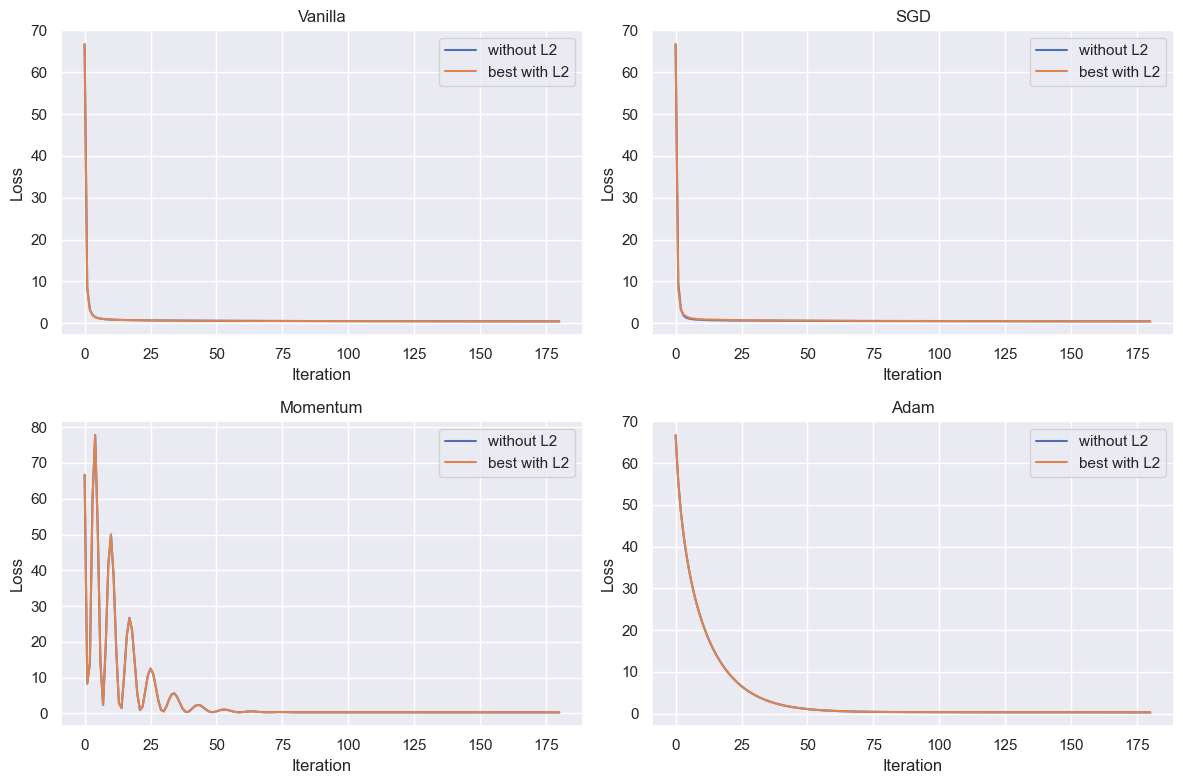

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, method in zip(axes.ravel(), methods):
    base_model = fitted_models[method]
    reg_model = regularized_models[method]
    ax.plot(base_model.loss_history, label='without L2')
    ax.plot(reg_model.loss_history, label='best with L2')
    ax.set_title(method)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Loss')
    ax.legend()
plt.tight_layout()
plt.show()


**Вывод.** L2-регуляризация слегка сдерживает веса и может улучшить качество на валидации/тесте, если модель переобучается на редкие one-hot признаки. На обучающей выборке ошибка с регуляризацией обычно выше, зато тестовое качество становится стабильнее.


## Задание 8. Альтернативные функции потерь (1 балл)

В этом задании вам предстоит использовать другую функцию потерь для нашей задачи регрессии. В качестве функции потерь мы выбрали **LogCosh** и **HuberLoss**:

$$
    L(y, a)
    =
    \log\left(\cosh(a - y)\right).
$$

$$
L_{\text{Huber}}(y, a) = \frac{1}{n} \sum_{i=1}^{n}
\begin{cases}
   \frac{1}{2} (a_i - y_i)^2, & \text{если } |a_i - y_i| < \delta, \\
   \delta \cdot |a_i - y_i| - \frac{1}{2} \delta^2, & \text{если } |a_i - y_i| \geq \delta,
\end{cases}
$$

Самостоятельно продифференцируем альтернативные функции потерь. Пусть $e_i = a_i - y_i$.

Для LogCosh: $L_i = \log(\cosh(e_i))$, поэтому $\frac{dL_i}{da_i} = \tanh(e_i)$.

Для Huber при $\delta=1$: если $|e_i| \le 1$, то $L_i = \frac{1}{2}e_i^2$ и $\frac{dL_i}{da_i}=e_i$; если $|e_i| > 1$, то $L_i = |e_i| - \frac{1}{2}$ и $\frac{dL_i}{da_i}=sign(e_i)$.

Матричный градиент получается умножением вектора производных по предсказаниям на $X^T$ и усреднением по объектам.


Программно реализуйте градиентный спуск с данными функциями потерь в файле `descents.py`, обучите все четыре метода (без регуляризации) аналогично 5 заданию, сравните их качество с четырьмя методами из 5 задания.

В этой версии альтернативные функции потерь реализованы в `linear_regression.py` через параметр `loss_function`.


In [34]:
alt_rows = []
for loss_function in [LossFunction.MSE, LossFunction.LogCosh, LossFunction.Huber]:
    for method in methods:
        lambda_ = best_results_5.loc[best_results_5['method'].eq(method), 'lambda'].iloc[0]
        model = LinearRegression(
            optimizer=make_optimizer(method, lambda_),
            tolerance=1e-8,
            max_iter=180,
            loss_function=loss_function,
        )
        model.fit(x_train, y_train)
        metrics = evaluate_model(model, x_train, y_train, x_val, y_val, x_test, y_test)
        alt_rows.append({'loss': loss_function.name, 'method': method, **metrics})

alt_results = pd.DataFrame(alt_rows)
alt_results.sort_values(['method', 'test_mse'])


,loss,method,train_mse,val_mse,test_mse,train_r2,test_r2,iterations
11,Huber,Adam,0.263643,0.249480,0.248751,0.763887,0.773570,180
7,LogCosh,Adam,0.264530,0.250240,0.249520,0.763093,0.772870,180
3,MSE,Adam,0.292225,0.277429,0.276984,0.738289,0.747870,180
2,MSE,Momentum,0.281927,0.270634,0.267079,0.747512,0.756887,180
10,Huber,Momentum,0.321809,0.313404,0.306783,0.711795,0.720745,180
6,LogCosh,Momentum,0.328563,0.320337,0.313618,0.705746,0.714524,180
1,MSE,SGD,0.451926,0.445966,0.437295,0.595265,0.601944,180
9,Huber,SGD,1.781793,1.770227,1.794256,-0.595735,-0.633254,180
5,LogCosh,SGD,1.848722,1.836349,1.862677,-0.655675,-0.695535,180
0,MSE,Vanilla,0.444476,0.438552,0.430288,0.601937,0.608322,180


**Вывод.** MSE остаётся самым естественным выбором для метрики MSE/R2. LogCosh и Huber устойчивее к выбросам: они меньше реагируют на крупные ошибки, поэтому могут проигрывать по MSE, но дают более робастную оптимизацию после логарифмирования цены.


### Кулинарно-социализационный бонус. (0.5 балла).

Как мы знаем, осень прекрасная пора, время пробовать новое и делиться теплом с друзьями и близкими. Выберите рецепт, который соответствует вашему настроению, приготовьте выбранное блюдо и угостите хотя бы одного человека им. Кратко опишите ваши впечатления, прикрепите рецепт и фотографии блюда и довольного гостя.